Libraries Imported Successfully

Running Device:
cpu

DATASET LOADED
Total Images : 1797
Image Shape  : (1797, 8, 8)
Labels Shape : (1797,)
Number of Classes : 10

PIXEL INFORMATION
Minimum Pixel Value: 0.0
Maximum Pixel Value: 16.0


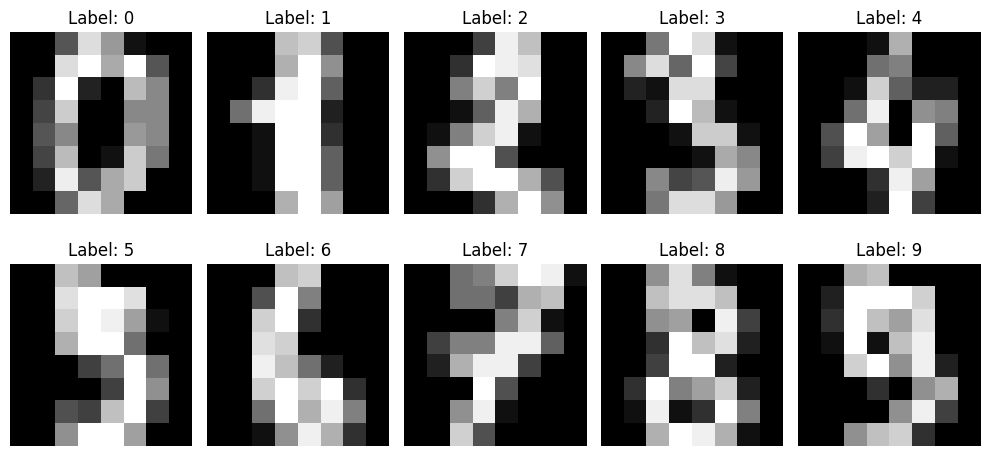


NORMALIZATION COMPLETED
Minimum: 0.0
Maximum: 1.0

CNN Input Shape:
(1797, 1, 8, 8)

DATASET SPLIT
Training Samples   : 1437
Validation Samples : 180
Testing Samples    : 180

PYTORCH TENSORS CREATED
Training Image Tensor: torch.Size([1437, 1, 8, 8])
Validation Image Tensor: torch.Size([180, 1, 8, 8])
Test Image Tensor: torch.Size([180, 1, 8, 8])

DATALOADERS CREATED
Batch Size: 32

SAMPLE BATCH
Image Batch Shape: torch.Size([32, 1, 8, 8])
Label Batch Shape: torch.Size([32])


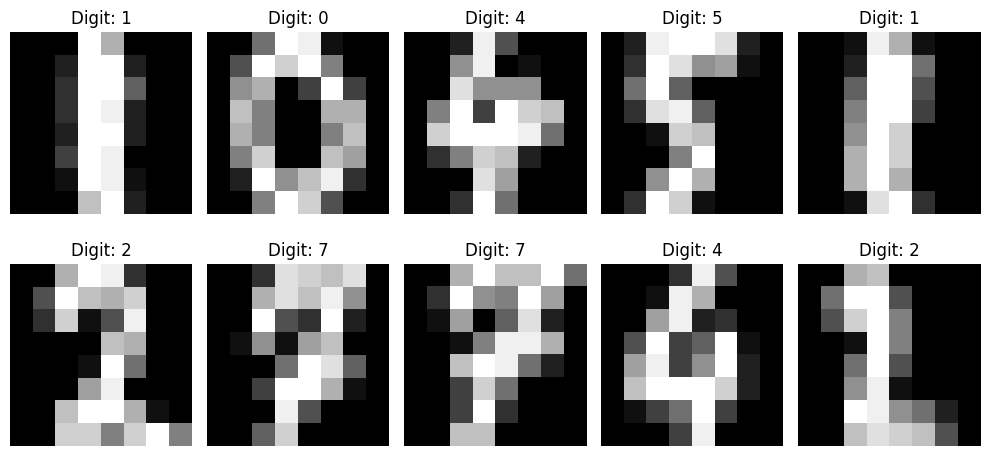


PART 1 DATASET SUMMARY

Dataset:
Scikit-learn Digits Dataset

Total Images:
1797

Image Resolution:
8 × 8

Image Type:
Grayscale

Number of Classes:
10

Classes:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9

Normalization:
0–16 → 0–1

Training:
80%

Validation:
10%

Testing:
10%

Batch Size:
32

Storage Requirement:
Very Small

CPU Usage:
Low


PART 1 COMPLETED SUCCESSFULLY

✔ Built-in dataset loaded
✔ No external dataset required
✔ Images explored
✔ Pixel values checked
✔ Images normalized
✔ CNN channel dimension added
✔ Train / validation / test split created
✔ PyTorch tensors created
✔ DataLoaders created

READY FOR PART 2



In [1]:
# ============================================================
# SECTION 1 : IMPORT LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import torch

from torch.utils.data import TensorDataset, DataLoader


print("Libraries Imported Successfully")


# ============================================================
# SECTION 2 : CHECK DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print()
print("Running Device:")
print(device)


# ============================================================
# SECTION 3 : LOAD BUILT-IN DATASET
# ============================================================

digits = load_digits()


X = digits.images

y = digits.target


print()
print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print("Total Images :", len(X))

print("Image Shape  :", X.shape)

print("Labels Shape :", y.shape)

print("Number of Classes :", len(np.unique(y)))


# ============================================================
# SECTION 4 : CHECK PIXEL VALUES
# ============================================================

print()
print("=" * 60)
print("PIXEL INFORMATION")
print("=" * 60)

print(
    "Minimum Pixel Value:",
    X.min()
)

print(
    "Maximum Pixel Value:",
    X.max()
)


# ============================================================
# SECTION 5 : DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(
    figsize=(10, 5)
)


for i in range(10):

    plt.subplot(
        2,
        5,
        i + 1
    )

    plt.imshow(
        X[i],
        cmap="gray"
    )

    plt.title(
        "Label: " + str(y[i])
    )

    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# SECTION 6 : NORMALIZE PIXEL VALUES
# ============================================================

# Original pixels are between 0 and 16.
#
# Convert them to 0-1.
#
# This makes training easier.


X = X / 16.0


print()
print("=" * 60)
print("NORMALIZATION COMPLETED")
print("=" * 60)

print(
    "Minimum:",
    X.min()
)

print(
    "Maximum:",
    X.max()
)


# ============================================================
# SECTION 7 : ADD CHANNEL DIMENSION
# ============================================================

# CNN expects:
#
# Batch × Channels × Height × Width
#
# Current shape:
#
# Images × Height × Width
#
# Add one grayscale channel.


X = X.reshape(
    -1,
    1,
    8,
    8
)


print()
print("CNN Input Shape:")
print(X.shape)


# ============================================================
# SECTION 8 : TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# First:
#
# 80% Training
# 20% Temporary
#
# Then temporary is divided into:
#
# 10% Validation
# 10% Test


X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp

)


print()
print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print(
    "Training Samples   :",
    len(X_train)
)

print(
    "Validation Samples :",
    len(X_val)
)

print(
    "Testing Samples    :",
    len(X_test)
)


# ============================================================
# SECTION 9 : CONVERT NUMPY → PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)


X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)


X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)


print()
print("=" * 60)
print("PYTORCH TENSORS CREATED")
print("=" * 60)

print(
    "Training Image Tensor:",
    X_train_tensor.shape
)

print(
    "Validation Image Tensor:",
    X_val_tensor.shape
)

print(
    "Test Image Tensor:",
    X_test_tensor.shape
)


# ============================================================
# SECTION 10 : CREATE DATASETS
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)


val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)


test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# ============================================================
# SECTION 11 : CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 32


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)


print()
print("=" * 60)
print("DATALOADERS CREATED")
print("=" * 60)

print(
    "Batch Size:",
    BATCH_SIZE
)


# ============================================================
# SECTION 12 : CHECK ONE BATCH
# ============================================================

sample_images, sample_labels = next(
    iter(train_loader)
)


print()
print("=" * 60)
print("SAMPLE BATCH")
print("=" * 60)

print(
    "Image Batch Shape:",
    sample_images.shape
)

print(
    "Label Batch Shape:",
    sample_labels.shape
)


# ============================================================
# SECTION 13 : VISUALIZE PROCESSED IMAGE
# ============================================================

plt.figure(
    figsize=(10, 5)
)


for i in range(10):

    plt.subplot(
        2,
        5,
        i + 1
    )

    image = sample_images[i].squeeze()

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        "Digit: "
        + str(sample_labels[i].item())
    )

    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# SECTION 14 : DATASET SUMMARY
# ============================================================

print()
print("=" * 60)
print("PART 1 DATASET SUMMARY")
print("=" * 60)

print("""
Dataset:
Scikit-learn Digits Dataset

Total Images:
1797

Image Resolution:
8 × 8

Image Type:
Grayscale

Number of Classes:
10

Classes:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9

Normalization:
0–16 → 0–1

Training:
80%

Validation:
10%

Testing:
10%

Batch Size:
32

Storage Requirement:
Very Small

CPU Usage:
Low
""")


# ============================================================
# SECTION 15 : PART 1 COMPLETION
# ============================================================

print()
print("=" * 60)
print("PART 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
✔ Built-in dataset loaded
✔ No external dataset required
✔ Images explored
✔ Pixel values checked
✔ Images normalized
✔ CNN channel dimension added
✔ Train / validation / test split created
✔ PyTorch tensors created
✔ DataLoaders created

READY FOR PART 2
""")

In [2]:
import torch
import torch.nn as nn


print("Part-2 Libraries Imported Successfully")


# ============================================================
# SECTION 2 : CHECK PART-1 VARIABLES
# ============================================================

print()
print("=" * 60)
print("CHECKING PART-1 COMPONENTS")
print("=" * 60)

print("Training Batches   :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches       :", len(test_loader))

print("Input Shape        :", sample_images.shape)

print("Number of Classes  :", len(np.unique(y)))


# ============================================================
# SECTION 3 : DEFINE CNN MODEL
# ============================================================

class SmallCNN(nn.Module):

    def __init__(self):

        super().__init__()


        # ----------------------------------------------------
        # CONVOLUTIONAL LAYER 1
        # ----------------------------------------------------

        self.conv1 = nn.Conv2d(

            in_channels=1,

            out_channels=16,

            kernel_size=3,

            padding=1

        )


        # ----------------------------------------------------
        # CONVOLUTIONAL LAYER 2
        # ----------------------------------------------------

        self.conv2 = nn.Conv2d(

            in_channels=16,

            out_channels=32,

            kernel_size=3,

            padding=1

        )


        # ----------------------------------------------------
        # MAX POOLING
        # ----------------------------------------------------

        self.pool = nn.MaxPool2d(

            kernel_size=2,

            stride=2

        )


        # ----------------------------------------------------
        # FULLY CONNECTED LAYER
        # ----------------------------------------------------

        # Input:
        #
        # 32 feature maps
        # 2 × 2 spatial size
        #
        # Therefore:
        #
        # 32 × 2 × 2 = 128


        self.fc1 = nn.Linear(

            32 * 2 * 2,

            64

        )


        # ----------------------------------------------------
        # OUTPUT LAYER
        # ----------------------------------------------------

        self.fc2 = nn.Linear(

            64,

            10

        )


        # ----------------------------------------------------
        # ACTIVATION
        # ----------------------------------------------------

        self.relu = nn.ReLU()


    # ========================================================
    # FORWARD PASS
    # ========================================================

    def forward(self, x):


        # First convolution

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)


        # Second convolution

        x = self.conv2(x)

        x = self.relu(x)

        x = self.pool(x)


        # Flatten

        x = x.view(
            x.size(0),
            -1
        )


        # Fully connected layer

        x = self.fc1(x)

        x = self.relu(x)


        # Output

        x = self.fc2(x)


        return x


# ============================================================
# SECTION 4 : CREATE MODEL
# ============================================================

model = SmallCNN()


# Move model to CPU/GPU

model = model.to(device)


print()
print("=" * 60)
print("CNN MODEL CREATED")
print("=" * 60)

print(model)


# ============================================================
# SECTION 5 : COUNT PARAMETERS
# ============================================================

total_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

)


trainable_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad

)


print()
print("=" * 60)
print("MODEL PARAMETERS")
print("=" * 60)

print(
    "Total Parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable Parameters:",
    f"{trainable_parameters:,}"
)


# ============================================================
# SECTION 6 : DEFINE LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()


print()
print("Loss Function:")
print(criterion)


# ============================================================
# SECTION 7 : DEFINE OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)


print()
print("Optimizer:")
print("Adam")

print("Learning Rate:")
print(0.001)


# ============================================================
# SECTION 8 : TEST FORWARD PASS
# ============================================================

# Take one batch from Part-1

images, labels = next(
    iter(train_loader)
)


# Move images to device

images = images.to(device)


# Forward pass

outputs = model(images)


print()
print("=" * 60)
print("FORWARD PASS TEST")
print("=" * 60)

print(
    "Input Shape:",
    images.shape
)

print(
    "Output Shape:",
    outputs.shape
)


# ============================================================
# SECTION 9 : CHECK PREDICTION
# ============================================================

predictions = torch.argmax(
    outputs,
    dim=1
)


print()
print("=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

print(
    "Predicted Labels:",
    predictions[:10].cpu().numpy()
)

print(
    "Actual Labels:",
    labels[:10].numpy()
)


# ============================================================
# SECTION 10 : CALCULATE SAMPLE LOSS
# ============================================================

labels = labels.to(device)


sample_loss = criterion(
    outputs,
    labels
)


print()
print("=" * 60)
print("SAMPLE LOSS")
print("=" * 60)

print(
    "Initial Loss:",
    sample_loss.item()
)


# ============================================================
# SECTION 11 : MODEL SUMMARY
# ============================================================

print()
print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

print("""
Input:
1 × 8 × 8

Conv Layer 1:
1 → 16 channels

Max Pool:
8 × 8 → 4 × 4

Conv Layer 2:
16 → 32 channels

Max Pool:
4 × 4 → 2 × 2

Flatten:
32 × 2 × 2 = 128

Fully Connected:
128 → 64

Output:
64 → 10 classes
""")


# ============================================================
# SECTION 12 : PART 2 COMPLETION
# ============================================================

print()
print("=" * 60)
print("PART 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
✔ Lightweight CNN created
✔ Model moved to device
✔ Parameters counted
✔ CrossEntropyLoss configured
✔ Adam optimizer configured
✔ Forward pass tested
✔ Sample loss calculated

READY FOR PART 3
""")

Part-2 Libraries Imported Successfully

CHECKING PART-1 COMPONENTS
Training Batches   : 45
Validation Batches : 6
Test Batches       : 6
Input Shape        : torch.Size([32, 1, 8, 8])
Number of Classes  : 10

CNN MODEL CREATED
SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

MODEL PARAMETERS
Total Parameters: 13,706
Trainable Parameters: 13,706

Loss Function:
CrossEntropyLoss()

Optimizer:
Adam
Learning Rate:
0.001

FORWARD PASS TEST
Input Shape: torch.Size([32, 1, 8, 8])
Output Shape: torch.Size([32, 10])

SAMPLE PREDICTIONS
Predicted Labels: [0 0 0 0 0 0 0 0 0 0]
Actual Labels: [9 7 6 4 2 0 3 1 4 8]

SAMPLE LOSS
Initial Loss: 2.3008198738098145

MOD

Part-3 Libraries Imported Successfully

TRAINING CONFIGURATION
Epochs      : 5
Device      : cpu
Batch Size  : 32

STARTING TRAINING
Epoch 1/5 | Train Loss: 2.2468 | Train Accuracy: 32.64% | Val Loss: 2.1323 | Val Accuracy: 45.00%
Epoch 2/5 | Train Loss: 1.7628 | Train Accuracy: 62.28% | Val Loss: 1.2948 | Val Accuracy: 77.78%
Epoch 3/5 | Train Loss: 0.9084 | Train Accuracy: 78.36% | Val Loss: 0.7810 | Val Accuracy: 81.11%
Epoch 4/5 | Train Loss: 0.5442 | Train Accuracy: 85.66% | Val Loss: 0.5175 | Val Accuracy: 86.67%
Epoch 5/5 | Train Loss: 0.3706 | Train Accuracy: 90.19% | Val Loss: 0.3757 | Val Accuracy: 88.33%

TRAINING COMPLETED


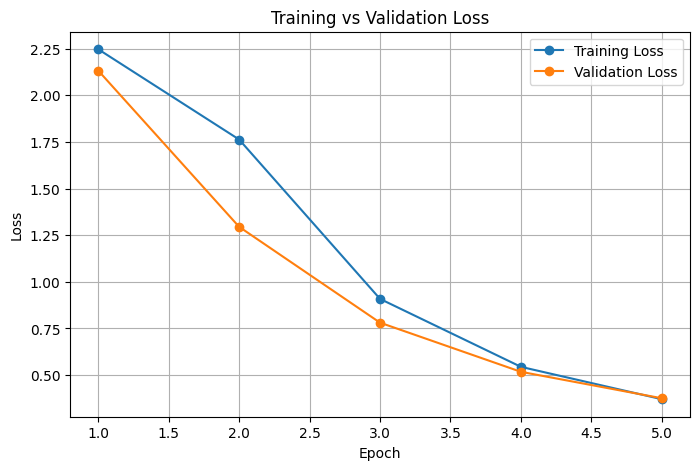

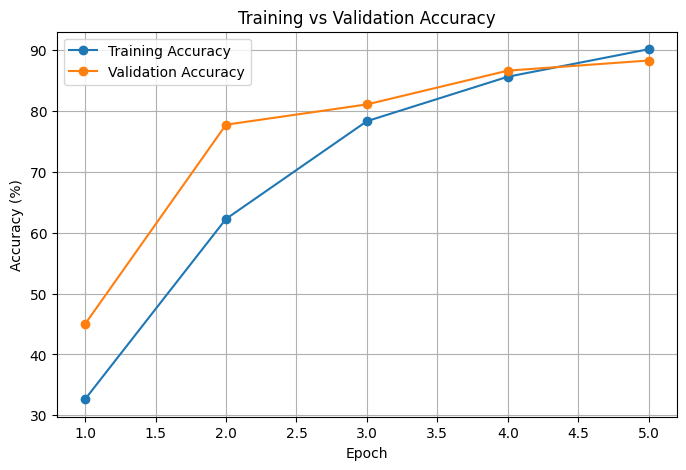


FINAL TEST EVALUATION
Test Loss: 0.3445
Test Accuracy: 88.33 %

SAMPLE TEST PREDICTIONS
Image 1: Actual = 3 | Predicted = 3
Image 2: Actual = 1 | Predicted = 1
Image 3: Actual = 4 | Predicted = 4
Image 4: Actual = 5 | Predicted = 5
Image 5: Actual = 8 | Predicted = 8
Image 6: Actual = 7 | Predicted = 7
Image 7: Actual = 5 | Predicted = 5
Image 8: Actual = 3 | Predicted = 3
Image 9: Actual = 0 | Predicted = 0
Image 10: Actual = 7 | Predicted = 7


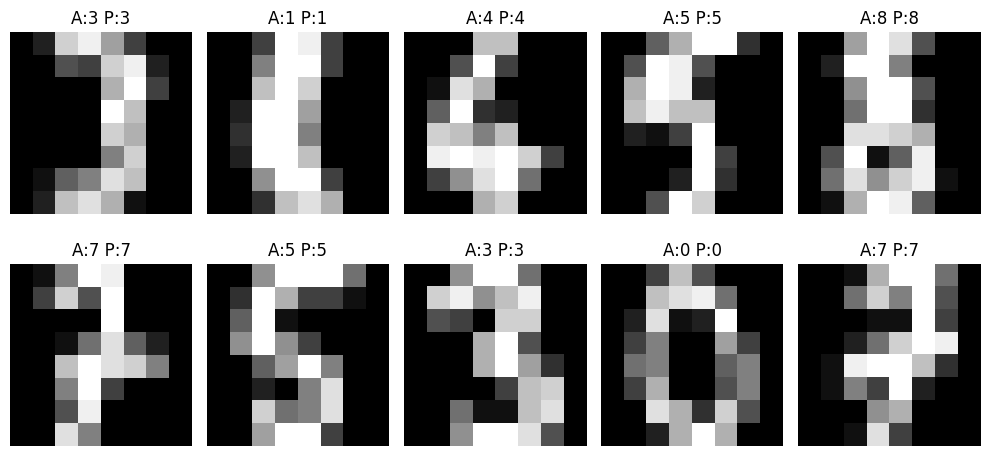


BEST VALIDATION RESULT
Best Epoch: 5
Best Validation Accuracy: 88.33 %

PART 3 COMPLETED SUCCESSFULLY

✔ CNN trained successfully

✔ Training loss recorded

✔ Validation loss recorded

✔ Training accuracy calculated

✔ Validation accuracy calculated

✔ Training curves plotted

✔ Final test evaluation completed

✔ Sample predictions generated

✔ Test predictions visualized

READY FOR PART 4



In [3]:
import torch
import matplotlib.pyplot as plt


print("Part-3 Libraries Imported Successfully")


# ============================================================
# SECTION 2 : TRAINING CONFIGURATION
# ============================================================

EPOCHS = 5


print()
print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Epochs      :", EPOCHS)

print("Device      :", device)

print("Batch Size  :", BATCH_SIZE)


# ============================================================
# SECTION 3 : CREATE HISTORY VARIABLES
# ============================================================

train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []


# ============================================================
# SECTION 4 : TRAINING LOOP
# ============================================================

print()
print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)


for epoch in range(EPOCHS):


    # --------------------------------------------------------
    # TRAINING MODE
    # --------------------------------------------------------

    model.train()


    total_train_loss = 0.0

    correct_train = 0

    total_train = 0


    # --------------------------------------------------------
    # TRAINING BATCHES
    # --------------------------------------------------------

    for images, labels in train_loader:


        # Move data to device

        images = images.to(device)

        labels = labels.to(device)


        # Clear previous gradients

        optimizer.zero_grad()


        # Forward pass

        outputs = model(images)


        # Calculate loss

        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation

        loss.backward()


        # Update weights

        optimizer.step()


        # Store loss

        total_train_loss += loss.item()


        # Get predictions

        predictions = torch.argmax(
            outputs,
            dim=1
        )


        # Count correct predictions

        correct_train += (
            predictions == labels
        ).sum().item()


        total_train += labels.size(0)


    # --------------------------------------------------------
    # TRAINING METRICS
    # --------------------------------------------------------

    average_train_loss = (

        total_train_loss
        /
        len(train_loader)

    )


    train_accuracy = (

        correct_train
        /
        total_train

    ) * 100


    train_losses.append(
        average_train_loss
    )


    train_accuracies.append(
        train_accuracy
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    total_val_loss = 0.0

    correct_val = 0

    total_val = 0


    with torch.no_grad():


        for images, labels in val_loader:


            # Move data to device

            images = images.to(device)

            labels = labels.to(device)


            # Forward pass

            outputs = model(images)


            # Calculate validation loss

            loss = criterion(
                outputs,
                labels
            )


            total_val_loss += loss.item()


            # Predictions

            predictions = torch.argmax(
                outputs,
                dim=1
            )


            # Count correct predictions

            correct_val += (
                predictions == labels
            ).sum().item()


            total_val += labels.size(0)


    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    average_val_loss = (

        total_val_loss
        /
        len(val_loader)

    )


    val_accuracy = (

        correct_val
        /
        total_val

    ) * 100


    val_losses.append(
        average_val_loss
    )


    val_accuracies.append(
        val_accuracy
    )


    # --------------------------------------------------------
    # PRINT EPOCH RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}% | "
        f"Val Loss: {average_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )


# ============================================================
# SECTION 5 : TRAINING COMPLETED
# ============================================================

print()
print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)


# ============================================================
# SECTION 6 : PLOT TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)


plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Training vs Validation Loss"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# SECTION 7 : PLOT TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)


plt.plot(
    range(1, EPOCHS + 1),
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "Training vs Validation Accuracy"
)


plt.legend()

plt.grid()

plt.show()


# ============================================================
# SECTION 8 : FINAL TEST EVALUATION
# ============================================================

print()
print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)


model.eval()


correct_test = 0

total_test = 0

total_test_loss = 0.0


with torch.no_grad():


    for images, labels in test_loader:


        # Move data to device

        images = images.to(device)

        labels = labels.to(device)


        # Forward pass

        outputs = model(images)


        # Calculate loss

        loss = criterion(
            outputs,
            labels
        )


        total_test_loss += loss.item()


        # Predictions

        predictions = torch.argmax(
            outputs,
            dim=1
        )


        # Count correct predictions

        correct_test += (
            predictions == labels
        ).sum().item()


        total_test += labels.size(0)


# ============================================================
# SECTION 9 : CALCULATE TEST METRICS
# ============================================================

test_loss = (

    total_test_loss
    /
    len(test_loader)

)


test_accuracy = (

    correct_test
    /
    total_test

) * 100


print(
    "Test Loss:",
    round(test_loss, 4)
)


print(
    "Test Accuracy:",
    round(test_accuracy, 2),
    "%"
)


# ============================================================
# SECTION 10 : TEST SAMPLE PREDICTIONS
# ============================================================

images, labels = next(
    iter(test_loader)
)


images = images.to(device)

labels = labels.to(device)


with torch.no_grad():

    outputs = model(images)

    predictions = torch.argmax(
        outputs,
        dim=1
    )


print()
print("=" * 60)
print("SAMPLE TEST PREDICTIONS")
print("=" * 60)


for i in range(
    min(10, len(images))
):

    print(
        f"Image {i + 1}: "
        f"Actual = {labels[i].item()} | "
        f"Predicted = {predictions[i].item()}"
    )


# ============================================================
# SECTION 11 : VISUALIZE TEST PREDICTIONS
# ============================================================

plt.figure(
    figsize=(10, 5)
)


for i in range(
    min(10, len(images))
):

    plt.subplot(
        2,
        5,
        i + 1
    )


    image = images[i].cpu().squeeze()


    plt.imshow(
        image,
        cmap="gray"
    )


    actual = labels[i].item()

    predicted = predictions[i].item()


    plt.title(
        f"A:{actual} P:{predicted}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# SECTION 12 : FIND BEST VALIDATION ACCURACY
# ============================================================

best_val_accuracy = max(
    val_accuracies
)


best_epoch = (
    val_accuracies.index(
        best_val_accuracy
    )
    + 1
)


print()
print("=" * 60)
print("BEST VALIDATION RESULT")
print("=" * 60)

print(
    "Best Epoch:",
    best_epoch
)


print(
    "Best Validation Accuracy:",
    round(
        best_val_accuracy,
        2
    ),
    "%"
)


# ============================================================
# SECTION 13 : PART 3 SUMMARY
# ============================================================

print()
print("=" * 60)
print("PART 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
✔ CNN trained successfully

✔ Training loss recorded

✔ Validation loss recorded

✔ Training accuracy calculated

✔ Validation accuracy calculated

✔ Training curves plotted

✔ Final test evaluation completed

✔ Sample predictions generated

✔ Test predictions visualized

READY FOR PART 4
""")


Part-4 Libraries Imported Successfully

MODEL SAVED
Model Path:
day50_deep_learning_cnn.pth

MODEL LOADED SUCCESSFULLY

SINGLE IMAGE INFERENCE
Actual Digit: 3
Predicted Digit: 3
Confidence: 72.97 %

Class Probabilities:
Digit 0: 0.06%
Digit 1: 1.08%
Digit 2: 17.12%
Digit 3: 72.97%
Digit 4: 0.00%
Digit 5: 0.40%
Digit 6: 0.00%
Digit 7: 0.04%
Digit 8: 4.82%
Digit 9: 3.51%


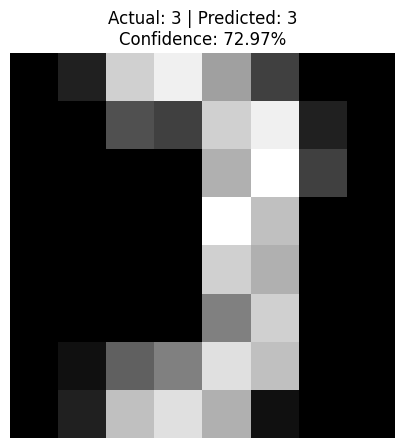


MULTIPLE IMAGE INFERENCE
Image 1: Actual = 3 | Predicted = 3 | Confidence = 72.97%
Image 2: Actual = 1 | Predicted = 1 | Confidence = 71.52%
Image 3: Actual = 4 | Predicted = 4 | Confidence = 83.29%
Image 4: Actual = 5 | Predicted = 5 | Confidence = 85.98%
Image 5: Actual = 8 | Predicted = 8 | Confidence = 48.11%
Image 6: Actual = 7 | Predicted = 7 | Confidence = 75.98%
Image 7: Actual = 5 | Predicted = 5 | Confidence = 92.48%
Image 8: Actual = 3 | Predicted = 3 | Confidence = 91.17%
Image 9: Actual = 0 | Predicted = 0 | Confidence = 98.29%
Image 10: Actual = 7 | Predicted = 7 | Confidence = 95.92%

Sample Inference Accuracy: 100.0 %


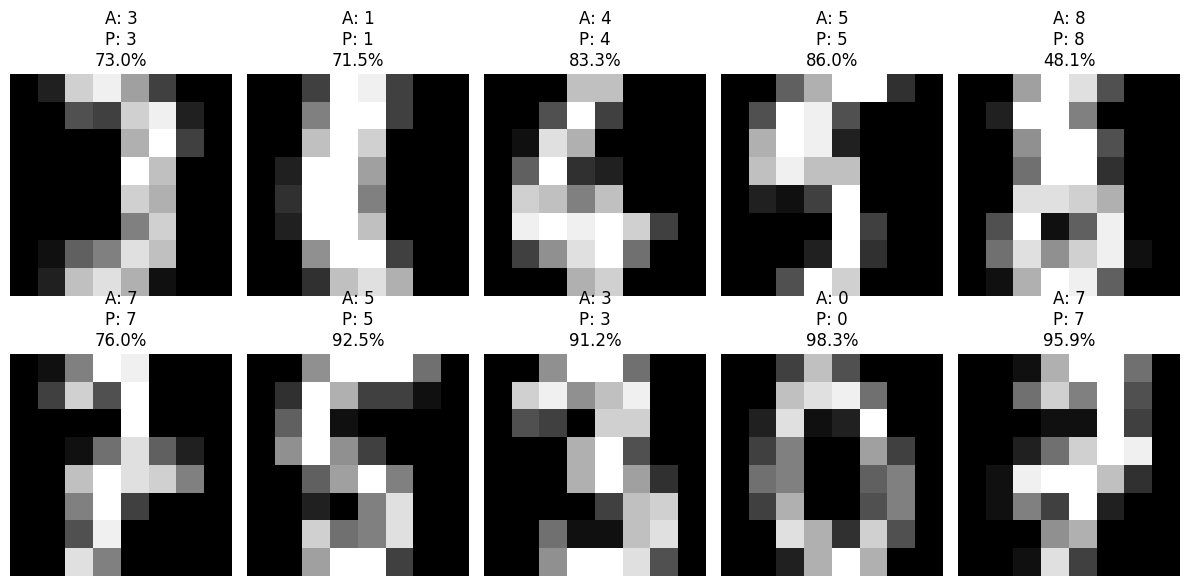


FINAL MODEL RESULTS
Total Test Images: 180
Correct Predictions: 159
Incorrect Predictions: 21
Final Test Accuracy: 88.33 %

DAY 50/100 — PROJECT COMPLETED

PROJECT:
End-to-End Deep Learning Image Classification

DATASET:
Scikit-learn Digits Dataset

MODEL:
Lightweight CNN

INPUT:
8 × 8 Grayscale Image

CLASSES:
10 Digits (0–9)

TRAINING:
CPU-Friendly

STORAGE:
Very Small

PIPELINE:
Dataset
   ↓
Preprocessing
   ↓
CNN
   ↓
Training
   ↓
Validation
   ↓
Testing
   ↓
Model Saving
   ↓
Inference
   ↓
Prediction + Confidence


COMPLETE PIPELINE

                 INPUT IMAGE
                      |
                      v
               PREPROCESSING
                      |
                      v
                  SMALL CNN
                      |
                      v
                  LOGITS
                      |
                      v
                SOFTMAX
                      |
                      v
              CLASS PROBABILITY
                      |
                     

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print("Part-4 Libraries Imported Successfully")


# ============================================================
# SECTION 2 : SAVE TRAINED MODEL
# ============================================================

MODEL_PATH = "day50_deep_learning_cnn.pth"


torch.save(
    model.state_dict(),
    MODEL_PATH
)


print()
print("=" * 60)
print("MODEL SAVED")
print("=" * 60)

print("Model Path:")
print(MODEL_PATH)


# ============================================================
# SECTION 3 : LOAD THE SAVED MODEL
# ============================================================

# Create a new model object

loaded_model = SmallCNN()


# Load trained weights

loaded_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)


# Move model to device

loaded_model = loaded_model.to(
    device
)


# Evaluation mode

loaded_model.eval()


print()
print("=" * 60)
print("MODEL LOADED SUCCESSFULLY")
print("=" * 60)


# ============================================================
# SECTION 4 : CREATE INFERENCE FUNCTION
# ============================================================

def predict_digit(image):

    """
    Takes one preprocessed image
    and returns:
    predicted digit
    confidence
    probabilities
    """

    # Add batch dimension

    image = image.unsqueeze(0)


    # Move image to device

    image = image.to(device)


    # Disable gradient calculation

    with torch.no_grad():

        # Model prediction

        output = loaded_model(
            image
        )


        # Convert logits to probabilities

        probabilities = F.softmax(
            output,
            dim=1
        )


        # Get highest probability

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )


    return (
        prediction.item(),
        confidence.item(),
        probabilities.squeeze(0)
    )


# ============================================================
# SECTION 5 : SELECT ONE TEST IMAGE
# ============================================================

test_image = X_test_tensor[0]

test_label = y_test_tensor[0].item()


# Make prediction

predicted_digit, confidence, probabilities = (
    predict_digit(test_image)
)


# ============================================================
# SECTION 6 : DISPLAY PREDICTION
# ============================================================

print()
print("=" * 60)
print("SINGLE IMAGE INFERENCE")
print("=" * 60)

print(
    "Actual Digit:",
    test_label
)

print(
    "Predicted Digit:",
    predicted_digit
)

print(
    "Confidence:",
    round(
        confidence * 100,
        2
    ),
    "%"
)


# ============================================================
# SECTION 7 : DISPLAY CLASS PROBABILITIES
# ============================================================

print()
print("Class Probabilities:")


for digit, probability in enumerate(
    probabilities
):

    print(
        f"Digit {digit}: "
        f"{probability.item() * 100:.2f}%"
    )


# ============================================================
# SECTION 8 : VISUALIZE SINGLE PREDICTION
# ============================================================

plt.figure(
    figsize=(5, 5)
)


plt.imshow(
    test_image.squeeze(),
    cmap="gray"
)


plt.title(
    f"Actual: {test_label} | "
    f"Predicted: {predicted_digit}\n"
    f"Confidence: {confidence * 100:.2f}%"
)


plt.axis("off")

plt.show()


# ============================================================
# SECTION 9 : TEST MULTIPLE IMAGES
# ============================================================

print()
print("=" * 60)
print("MULTIPLE IMAGE INFERENCE")
print("=" * 60)


number_of_samples = min(
    10,
    len(X_test_tensor)
)


correct_predictions = 0


for i in range(
    number_of_samples
):

    image = X_test_tensor[i]

    actual = y_test_tensor[i].item()


    predicted, confidence, _ = (
        predict_digit(image)
    )


    if predicted == actual:

        correct_predictions += 1


    print(
        f"Image {i + 1}: "
        f"Actual = {actual} | "
        f"Predicted = {predicted} | "
        f"Confidence = "
        f"{confidence * 100:.2f}%"
    )


# ============================================================
# SECTION 10 : MULTIPLE IMAGE ACCURACY
# ============================================================

sample_accuracy = (

    correct_predictions
    /
    number_of_samples

) * 100


print()
print(
    "Sample Inference Accuracy:",
    round(
        sample_accuracy,
        2
    ),
    "%"
)


# ============================================================
# SECTION 11 : VISUALIZE MULTIPLE PREDICTIONS
# ============================================================

plt.figure(
    figsize=(12, 6)
)


for i in range(
    number_of_samples
):

    image = X_test_tensor[i]


    predicted, confidence, _ = (
        predict_digit(image)
    )


    actual = y_test_tensor[i].item()


    plt.subplot(
        2,
        5,
        i + 1
    )


    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )


    plt.title(
        f"A: {actual}\n"
        f"P: {predicted}\n"
        f"{confidence * 100:.1f}%"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# SECTION 12 : FINAL TEST SET PREDICTION
# ============================================================

correct = 0

total = 0


all_predictions = []

all_actuals = []


for i in range(
    len(X_test_tensor)
):

    image = X_test_tensor[i]

    actual = y_test_tensor[i].item()


    predicted, confidence, _ = (
        predict_digit(image)
    )


    all_predictions.append(
        predicted
    )

    all_actuals.append(
        actual
    )


    if predicted == actual:

        correct += 1


    total += 1


final_accuracy = (

    correct / total

) * 100


# ============================================================
# SECTION 13 : FINAL RESULTS
# ============================================================

print()
print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print(
    "Total Test Images:",
    total
)

print(
    "Correct Predictions:",
    correct
)

print(
    "Incorrect Predictions:",
    total - correct
)

print(
    "Final Test Accuracy:",
    round(
        final_accuracy,
        2
    ),
    "%"
)


# ============================================================
# SECTION 14 : FINAL PROJECT SUMMARY
# ============================================================

print()
print("=" * 60)
print("DAY 50/100 — PROJECT COMPLETED")
print("=" * 60)

print("""
PROJECT:
End-to-End Deep Learning Image Classification

DATASET:
Scikit-learn Digits Dataset

MODEL:
Lightweight CNN

INPUT:
8 × 8 Grayscale Image

CLASSES:
10 Digits (0–9)

TRAINING:
CPU-Friendly

STORAGE:
Very Small

PIPELINE:
Dataset
   ↓
Preprocessing
   ↓
CNN
   ↓
Training
   ↓
Validation
   ↓
Testing
   ↓
Model Saving
   ↓
Inference
   ↓
Prediction + Confidence
""")


# ============================================================
# SECTION 15 : COMPLETE END-TO-END PIPELINE
# ============================================================

print()
print("=" * 60)
print("COMPLETE PIPELINE")
print("=" * 60)

print("""
                 INPUT IMAGE
                      |
                      v
               PREPROCESSING
                      |
                      v
                  SMALL CNN
                      |
                      v
                  LOGITS
                      |
                      v
                SOFTMAX
                      |
                      v
              CLASS PROBABILITY
                      |
                      v
            PREDICTED DIGIT
                      |
                      v
               CONFIDENCE
""")


print()
print("=" * 60)
print("ALL 4 PARTS COMPLETED")
print("=" * 60)

print("""
PART 1 → Dataset + Preprocessing
PART 2 → CNN Model Development
PART 3 → Training + Evaluation
PART 4 → Saving + Inference

DAY 50/100 COMPLETE ✔
""")